In [122]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, concatenate
from tensorflow.keras.optimizers import Adam
import random
from collections import deque
import pandas as pd
import os
from datetime import datetime
import logging
import matplotlib.pyplot as plt

In [123]:
def create_model_directory(path_template):
    i = 1
    while True:
        path = path_template.format(i = i, date=datetime.now().strftime("%Y-%m-%d"))
        if not os.path.exists(path):
            os.makedirs(path)
            return path
        i += 1

# Usage example
path_template = './TD3_models/{date}/{i}'
model_dir = create_model_directory(path_template)
print(f"Model directory created: {model_dir}")

Model directory created: ./TD3_models/2024-08-04/7


In [124]:
# Configure logging
log = logging.getLogger()

# 로그의 레벨
log.setLevel(logging.INFO)

# log 출력 형식
formatter = logging.Formatter('[ %(asctime)s | %(levelname)s ] %(message)s')

# log를 파일에 출력
file_handler = logging.FileHandler(f"{model_dir}/training.log")
file_handler.setFormatter(formatter)
log.addHandler(file_handler)

In [125]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [126]:
# Hyperparameters
STATE_SIZE = 7  # Open, Close, High, Low, SMA_5, SMA_10, SMA_20
ACTION_SIZE = 1  # Number of actions (e.g., buy, sell, hold)
BUFFER_SIZE = 500000  # Increased buffer size for more diverse experience replay
BATCH_SIZE = 128  # Larger batch size for more stable updates
GAMMA = 0.995  # Slightly lower discount factor to focus more on immediate rewards
TAU = 0.005  # Faster soft update for quicker adaptation
LR_ACTOR = 0.0005  # Slower learning rate for more stable actor updates
LR_CRITIC = 0.001  # Moderate learning rate for critic updates
POLICY_NOISE = 0.15  # Reduced noise for more focused exploration
NOISE_CLIP = 0.5  # Tighter noise clip for more controlled exploration
POLICY_FREQ = 1  # Less frequent policy updates for stability
EXPLORATION_NOISE = 0.05  # Initial exploration noise, gradually reduced
LEARNING_RATE_DECAY = 0.99995  # Slower learning rate decay for longer-term stability

In [127]:
# Budget
BUDGET = 1000000  #1,000,000

In [128]:
class StockTradingEnvironment:
    def __init__(self, data, budget=BUDGET):
        self.data = data[['Open', 'Close', 'High', 'Low']].values
        self.data_mean = np.mean(self.data, axis=0)
        self.data_std = np.std(self.data, axis=0)
        self.data = (self.data - self.data_mean) / (self.data_std + 1e-8)  # Normalization
        # Add technical indicators
        self.data = self._add_technical_indicators(data)
        self.budget = budget
        self.current_step = 0
        self.inventory = []
        self.portfolio_value = budget
        
    def _add_technical_indicators(self, data):
        data['SMA_5'] = data['Close'].rolling(window=5).mean()
        data['SMA_10'] = data['Close'].rolling(window=10).mean()
        data['SMA_20'] = data['Close'].rolling(window=20).mean()
        data = data.dropna()  # Drop rows with NaN values
        tech_indicators = data[['SMA_5', 'SMA_10', 'SMA_20']].values
        tech_indicators_mean = np.mean(tech_indicators, axis=0)
        tech_indicators_std = np.std(tech_indicators, axis=0)
        tech_indicators = (tech_indicators - tech_indicators_mean) / (tech_indicators_std + 1e-8)  # Normalization
        self.data = data[['Open', 'Close', 'High', 'Low']].values  # Update self.data to match the length of tech_indicators
        self.data = (self.data - self.data_mean) / (self.data_std + 1e-8)  # Re-normalize the updated self.data
        self.data = np.hstack((self.data, tech_indicators))
        return self.data

    def reset(self):
        self.current_step = 0
        self.inventory = []
        self.portfolio_value = self.budget
        return self._get_state()

    def step(self, action):
        done = False
        reward = 0
        current_price = self.data[self.current_step, 1]  # Close price

        if action == 0:  # Hold
            reward = 0  # No reward for holding
        elif action == 1:  # Buy
            max_buyable_quantity = min(self.budget // current_price, 100)  # Limit buy quantity
            if max_buyable_quantity > 0:
                self.inventory.append([current_price, max_buyable_quantity])  # Add to inventory
                self.budget -= max_buyable_quantity * current_price
                log.info(f"Bought {max_buyable_quantity} shares at price {current_price} | Portfolio Value = {self.portfolio_value} | Budget = {self.budget} | inventory = {len(self.inventory)}")
        elif action == 2 and len(self.inventory) > 0:  # Sell
            bought_price, bought_quantity = self.inventory.pop(0)  # Remove from inventory
            self.budget += bought_quantity * current_price
            profit = (current_price - bought_price) * bought_quantity  # Calculate profit
            reward = profit
            log.info(f"Sold {bought_quantity} shares at price {current_price} | Profit = {profit} | Portfolio Value = {self.portfolio_value} | Budget = {self.budget} | inventory = {len(self.inventory)}")

        previous_portfolio_value = self.portfolio_value
        self.portfolio_value = self.budget + sum(item[1] for item in self.inventory) * current_price

        # Calculate reward based on the change in portfolio value
        reward += (self.portfolio_value - previous_portfolio_value) / 10000  # Scaling the reward

        if self.current_step == len(self.data) - 1:
            done = True
        else:
            self.current_step += 1

        next_state = self._get_state()
        return next_state, reward, done

    def _get_state(self):
        return self.data[self.current_step]

In [129]:
class ReplayBuffer:
    def __init__(self, buffer_size):
        self.buffer = deque(maxlen=buffer_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return states, actions, rewards, next_states, dones

In [130]:
class Actor(Model):
    def __init__(self, action_size):
        super(Actor, self).__init__()
        self.fc1 = Dense(512, activation='relu')
        self.fc2 = Dense(256, activation='relu')
        self.action = Dense(action_size, activation='tanh')

    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        action = self.action(x)
        return action

class Critic(Model):
    def __init__(self):
        super(Critic, self).__init__()
        self.fc1 = Dense(512, activation='relu')
        self.fc2 = Dense(256, activation='relu')
        self.q = Dense(1, activation=None)

    def call(self, state, action):
        action = tf.reshape(action, [-1, 1])  # Reshape action to match the state tensor
        x = concatenate([state, action], axis=-1)
        x = self.fc1(x)
        x = self.fc2(x)
        q = self.q(x)
        return q

In [131]:
class TD3Agent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.actor = Actor(action_size)
        self.critic1 = Critic()
        self.critic2 = Critic()
        self.target_actor = Actor(action_size)
        self.target_critic1 = Critic()
        self.target_critic2 = Critic()
        self.actor_optimizer = Adam(LR_ACTOR)
        self.critic1_optimizer = Adam(LR_CRITIC)
        self.critic2_optimizer = Adam(LR_CRITIC)
        self.replay_buffer = ReplayBuffer(BUFFER_SIZE)
        self.update_target_networks(tau=1)
        self.train_step = 0  # Initialize train_step
        self.exploration_noise = EXPLORATION_NOISE
        self.learning_rate_decay = LEARNING_RATE_DECAY  # Adjusted learning rate decay factor

    def update_target_networks(self, tau=TAU):
        actor_weights = self.actor.get_weights()
        target_actor_weights = self.target_actor.get_weights()
        for i in range(len(actor_weights)):
            target_actor_weights[i] = tau * actor_weights[i] + (1 - tau) * target_actor_weights[i]
        self.target_actor.set_weights(target_actor_weights)

        critic1_weights = self.critic1.get_weights()
        target_critic1_weights = self.target_critic1.get_weights()
        for i in range(len(critic1_weights)):
            target_critic1_weights[i] = tau * critic1_weights[i] + (1 - tau) * target_critic1_weights[i]
        self.target_critic1.set_weights(target_critic1_weights)

        critic2_weights = self.critic2.get_weights()
        target_critic2_weights = self.target_critic2.get_weights()
        for i in range(len(critic2_weights)):
            target_critic2_weights[i] = tau * critic2_weights[i] + (1 - tau) * target_critic2_weights[i]
        self.target_critic2.set_weights(target_critic2_weights)

    def select_action(self, state):
        state = np.expand_dims(state, axis=0)
        action = self.actor(state).numpy()[0]
        
        # Add exploration noise
        noise = np.random.normal(0, self.exploration_noise)
        action = np.clip(action + noise, -1, 1)
        
        # Map continuous action to discrete action (0: Hold, 1: Buy, 2: Sell)
        if action < -0.5:
            discrete_action = 2  # Sell
        elif action > 0.5:
            discrete_action = 1  # Buy
        else:
            discrete_action = 0  # Hold
        
        return discrete_action

    def train(self):
        if len(self.replay_buffer.buffer) < BATCH_SIZE:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)

        next_actions = self.target_actor(next_states)
        noise = np.random.normal(0, POLICY_NOISE, size=next_actions.shape)
        noise = np.clip(noise, -NOISE_CLIP, NOISE_CLIP)
        next_actions = next_actions + noise
        next_actions = np.clip(next_actions, -1, 1)

        target_q1 = self.target_critic1(next_states, next_actions).numpy()
        target_q2 = self.target_critic2(next_states, next_actions).numpy()
        target_q = np.minimum(target_q1, target_q2)
        target_q = rewards + (1 - dones) * GAMMA * target_q

        with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
            q1 = self.critic1(states, actions)
            q2 = self.critic2(states, actions)
            critic1_loss = tf.reduce_mean((q1 - target_q) ** 2)
            critic2_loss = tf.reduce_mean((q2 - target_q) ** 2)

        critic1_grads = tape1.gradient(critic1_loss, self.critic1.trainable_variables)
        critic2_grads = tape2.gradient(critic2_loss, self.critic2.trainable_variables)
        self.critic1_optimizer.apply_gradients(zip(critic1_grads, self.critic1.trainable_variables))
        self.critic2_optimizer.apply_gradients(zip(critic2_grads, self.critic2.trainable_variables))

        actor_loss = 0.0  # Initialize actor_loss with a default value

        if self.train_step % POLICY_FREQ == 0:
            with tf.GradientTape() as tape:
                actor_actions = self.actor(states)
                actor_loss = -tf.reduce_mean(self.critic1(states, actor_actions))

            actor_grads = tape.gradient(actor_loss, self.actor.trainable_variables)
            self.actor_optimizer.apply_gradients(zip(actor_grads, self.actor.trainable_variables))

            self.update_target_networks()

        self.train_step += 1
        self.exploration_noise *= 0.9995  # Gradually reduce exploration noise
        self.actor_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay
        self.critic1_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay
        self.critic2_optimizer.learning_rate *= self.learning_rate_decay  # Apply learning rate decay

        # Logging losses
        actor_loss_value = actor_loss if isinstance(actor_loss, tf.Tensor) else tf.constant(actor_loss, dtype=tf.float32)

    def add_to_buffer(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def save_models(self, path):
        # Save the models
        self.actor.save(f'{path}/actor_model.keras')
        self.critic1.save(f'{path}/critic1_model.keras')
        self.critic2.save(f'{path}/critic2_model.keras')

    def load_models(self, path):
        self.actor = tf.keras.models.load_model(path + '/actor_model.keras')
        self.critic1 = tf.keras.models.load_model(path + '/critic1_model.keras')
        self.critic2 = tf.keras.models.load_model(path + '/critic2_model.keras')
        self.target_actor = tf.keras.models.load_model(path + '/actor_model.keras')
        self.target_critic1 = tf.keras.models.load_model(path + '/critic1_model.keras')
        self.target_critic2 = tf.keras.models.load_model(path + '/critic2_model.keras')

In [132]:
def train_agent(agent, env, episodes):    
    episode_rewards = []
    evaluation_rewards = []
    best_reward = -float('inf')
    patience = 10  # Increased patience
    no_improvement_count = 0

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            agent.add_to_buffer(state, action, reward, next_state, done)
            agent.train()
            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)

        if total_reward > best_reward:
            best_reward = total_reward
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            log.info(f"Early stopping at episode {episode + 1}")
            print(f"Early stopping at episode {episode + 1}")
            break

        log.info(f"Episode: {episode + 1}, Total Reward: {total_reward}")
        log.info('-' * 100)
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}")

        # Evaluate the agent periodically
        if episode % 10 == 0:
            average_reward = evaluate_agent(agent, env, episodes=10)
            evaluation_rewards.append(average_reward)
            log.info(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward}")
            print(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward}")
        
    agent.save_models(model_dir)
    log.info('-*' * 40 + ' Summary ' + '-*' * 40)
    log.info(f"Training completed. Best Average Reward: {best_reward}")
    for i in range(len(episode_rewards)):
        log.info(f"Episode: {i + 1}, Total Reward: {episode_rewards[i]}")

    return episode_rewards, evaluation_rewards

In [133]:
def evaluate_agent(agent, env, episodes):
    total_rewards = []
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            state = next_state
            total_reward += reward

        total_rewards.append(total_reward)
    return np.mean(total_rewards)

In [134]:
data = pd.read_csv('./datas/samsung.csv')  # Load your stock data here

In [135]:
env = StockTradingEnvironment(data)
agent = TD3Agent(STATE_SIZE, ACTION_SIZE)

In [137]:
episode_rewards, evaluation_rewards = train_agent(agent, env, episodes=50)

Episode: 1, Total Reward: 0.0
Evaluation at Episode 1: Average Reward: 0.0
Episode: 2, Total Reward: 0.0
Episode: 3, Total Reward: 0.0
Episode: 4, Total Reward: 0.0
Episode: 5, Total Reward: 0.0
Episode: 6, Total Reward: 0.0
Episode: 7, Total Reward: 0.0
Episode: 8, Total Reward: 2.1591375461863818
Episode: 9, Total Reward: 2.1591375461863818
Episode: 10, Total Reward: 2.1591375461863818
Episode: 11, Total Reward: 2.0212966805671804
Evaluation at Episode 11: Average Reward: 1.9790358235356984
Episode: 12, Total Reward: 1.9530410750837186
Episode: 13, Total Reward: 1.9743155495201243
Episode: 14, Total Reward: 2.0463385098516946
Episode: 15, Total Reward: 1.9410741832132334
Episode: 16, Total Reward: 1.784396543353458
Episode: 17, Total Reward: 1.8546466308153349
Early stopping at episode 18


In [95]:
def visualize_training_report(episode_rewards, evaluation_rewards, episodes):
    plt.figure(figsize=(12, 6))

    # Plot episode rewards
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Learning Curve')

    # Plot evaluation rewards
    plt.subplot(1, 2, 2)
    plt.plot(range(0, episodes, 10), evaluation_rewards, marker='o')
    plt.xlabel('Episode')
    plt.ylabel('Average Evaluation Reward')
    plt.title('Evaluation Rewards')

    plt.tight_layout()
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

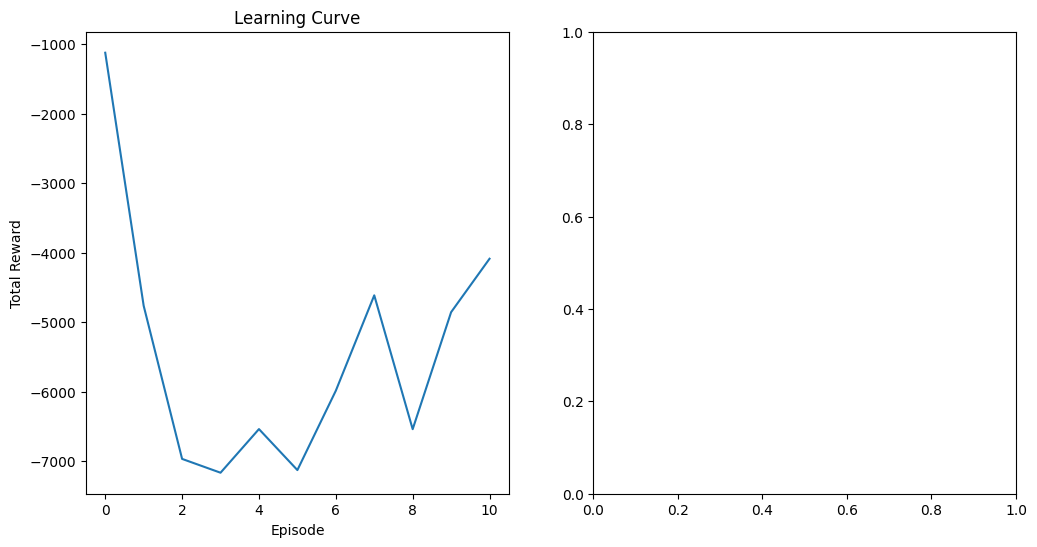

In [1155]:
visualize_training_report(episode_rewards, evaluation_rewards, episodes=100)

In [ ]:
# Evaluate the agent after training
average_reward = evaluate_agent(agent, env, episodes=10)
print(f"Average Evaluation Reward: {average_reward}")